# Sistema Fuzzy-Mandani - Irrigação Inteligente

## 1. Descrição do problema

O problema escolhido foi a recomendação da intensidade de irrigação em um sistema agrícola.

O objetivo é determinar quanto irrigar com base em três variáveis:

- Umidade do solo
- Temperatura ambiente
- Luminosidade solar

A saída do sistema é a intensidade de irrigação, representando o quanto de água deve ser aplicado.

## 2. Definição das variáveis

### Entradas:
- Umidade do solo (%)
- Temperatura (°C)
- Luminosidade (%)

### Saída:
- Intensidade de irrigação (%)

## 3. Universos de discurso



In [1]:
import numpy as np

umidade_universo = np.arange(0, 101, 1)
temperatura_universo = np.arange(0, 41, 1)
luminosidade_universo = np.arange(0, 101, 1)
irrigacao_universo = np.arange(0, 101, 1)

## 4. Termos linguísticos

Cada variável foi modelada com três termos linguísticos:

### Umidade:
- Baixa
- Média
- Alta

### Temperatura:
- Baixa
- Média
- Alta

### Luminosidade:
- Baixa
- Média
- Alta

### Irrigação:
- Baixa
- Média
- Alta

## 5. Funções de pertinência

Foram utilizadas funções triangulares (trimf).

In [2]:
def trimf(x, a, b, c):
    if x <= a:
        return 0
    elif a < x <= b:
        return (x - a) / (b - a)
    elif b < x < c:
        return (c - x) / (c - b)
    else:
        return 0

Equação da função triangular:

μ(x) = max(min((x-a)/(b-a), (c-x)/(c-b)), 0)

In [3]:
def umidade_baixa(x): return trimf(x, 0, 0, 50)
def umidade_media(x): return trimf(x, 25, 50, 75)
def umidade_alta(x): return trimf(x, 50, 100, 100)

def temperatura_baixa(x): return trimf(x, 0, 0, 20)
def temperatura_media(x): return trimf(x, 10, 22, 34)
def temperatura_alta(x): return trimf(x, 25, 40, 40)

def luminosidade_baixa(x): return trimf(x, 0, 0, 50)
def luminosidade_media(x): return trimf(x, 25, 50, 75)
def luminosidade_alta(x): return trimf(x, 50, 100, 100)

def irrigacao_baixa(y): return trimf(y, 0, 0, 50)
def irrigacao_media(y): return trimf(y, 25, 50, 75)
def irrigacao_alta(y): return trimf(y, 50, 100, 100)

## 6. Base de regras

In [4]:
regras = [
("umidade_baixa","temperatura_alta","luminosidade_alta","alta"),
("umidade_baixa","temperatura_media","luminosidade_alta","alta"),
("umidade_baixa","temperatura_media","luminosidade_media","media"),
("umidade_media","temperatura_alta","luminosidade_alta","media"),
("umidade_media","temperatura_media","luminosidade_media","media"),
("umidade_media","temperatura_baixa","luminosidade_baixa","baixa"),
("umidade_alta","temperatura_alta","luminosidade_alta","baixa"),
("umidade_alta","temperatura_media","luminosidade_media","baixa"),
("umidade_alta","temperatura_baixa","luminosidade_baixa","baixa"),
("umidade_alta","temperatura_alta","luminosidade_baixa","baixa")
]

## 7. Valores de entrada testados

In [5]:
testes = [
    (20, 35, 90),
    (55, 22, 50),
    (90, 15, 20)
]

## 8. Fuzzificação

In [6]:
def fuzzificar(u,t,l):
    return {
        "umidade_baixa": umidade_baixa(u),
        "umidade_media": umidade_media(u),
        "umidade_alta": umidade_alta(u),

        "temperatura_baixa": temperatura_baixa(t),
        "temperatura_media": temperatura_media(t),
        "temperatura_alta": temperatura_alta(t),

        "luminosidade_baixa": luminosidade_baixa(l),
        "luminosidade_media": luminosidade_media(l),
        "luminosidade_alta": luminosidade_alta(l)
    }

In [7]:
graus = fuzzificar(*testes[0])
graus

{'umidade_baixa': 0.6,
 'umidade_media': 0,
 'umidade_alta': 0,
 'temperatura_baixa': 0,
 'temperatura_media': 0,
 'temperatura_alta': 0.6666666666666666,
 'luminosidade_baixa': 0,
 'luminosidade_media': 0,
 'luminosidade_alta': 0.8}

## 9. Grau de ativação das regras

In [8]:
def aplicar_regras(graus):
    ativacoes = []

    for r in regras:
        g = min(graus[r[0]], graus[r[1]], graus[r[2]])
        ativacoes.append((r, g))

    return ativacoes

In [9]:
ativacoes = aplicar_regras(graus)
ativacoes

[(('umidade_baixa', 'temperatura_alta', 'luminosidade_alta', 'alta'), 0.6),
 (('umidade_baixa', 'temperatura_media', 'luminosidade_alta', 'alta'), 0),
 (('umidade_baixa', 'temperatura_media', 'luminosidade_media', 'media'), 0),
 (('umidade_media', 'temperatura_alta', 'luminosidade_alta', 'media'), 0),
 (('umidade_media', 'temperatura_media', 'luminosidade_media', 'media'), 0),
 (('umidade_media', 'temperatura_baixa', 'luminosidade_baixa', 'baixa'), 0),
 (('umidade_alta', 'temperatura_alta', 'luminosidade_alta', 'baixa'), 0),
 (('umidade_alta', 'temperatura_media', 'luminosidade_media', 'baixa'), 0),
 (('umidade_alta', 'temperatura_baixa', 'luminosidade_baixa', 'baixa'), 0),
 (('umidade_alta', 'temperatura_alta', 'luminosidade_baixa', 'baixa'), 0)]

## 10. Saída fuzzy agregada

In [10]:
def calcular_saida_agregada(ativacoes):
    saida = []

    for y in irrigacao_universo:
        valores = []

        for r, g in ativacoes:
            if r[3] == "baixa":
                mu = irrigacao_baixa(y)
            elif r[3] == "media":
                mu = irrigacao_media(y)
            else:
                mu = irrigacao_alta(y)

            valores.append(min(g, mu))

        saida.append(max(valores))

    return np.array(saida)

In [11]:
saida_agregada = calcular_saida_agregada(ativacoes)

## 11. Defuzzificação

In [12]:
def defuzzificar(saida):
    num = np.sum(irrigacao_universo * saida)
    den = np.sum(saida)
    return num/den if den != 0 else 0

In [13]:
valor_final = defuzzificar(saida_agregada)
valor_final

np.float64(81.69483568075113)

## 12. Gráficos das funções de pertinência

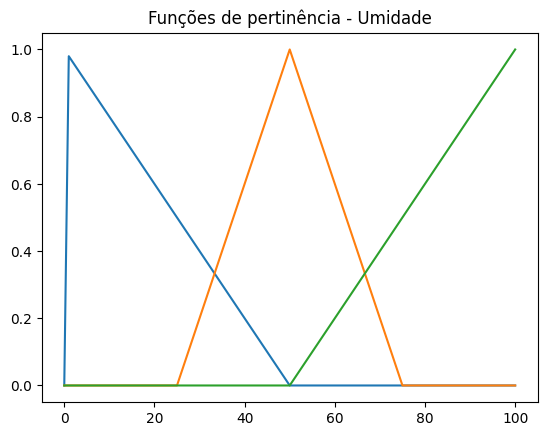

In [14]:
import matplotlib.pyplot as plt

plt.plot(umidade_universo, [umidade_baixa(x) for x in umidade_universo])
plt.plot(umidade_universo, [umidade_media(x) for x in umidade_universo])
plt.plot(umidade_universo, [umidade_alta(x) for x in umidade_universo])
plt.title("Funções de pertinência - Umidade")
plt.show()

## 13. Saída agregada

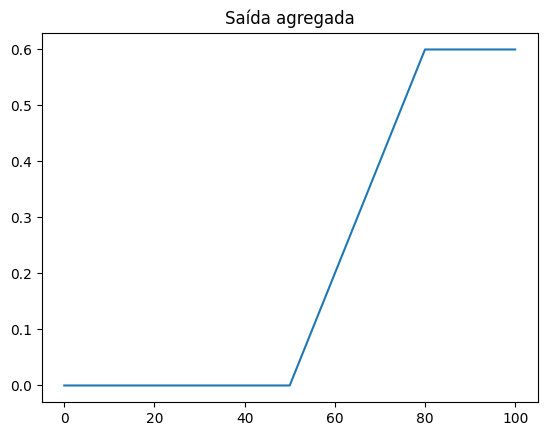

In [15]:
plt.plot(irrigacao_universo, saida_agregada)
plt.title("Saída agregada")
plt.show()